In [57]:
cd /home/sam/cc-net

/home/sam/cc-net


/home/sam/anaconda3/envs/py10-coreset/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [58]:
import numpy as np
import graphlearning as gl

In [59]:
def generate_recursive_hierarchy(
    branching,
    points_per_leaf=50,
    level_scales=None,
    dim=2,
    random_state=None,
):
    """
    branching: list like [3, 4, 2]
        3 clusters at level 1, each with 4 at level 2, each with 2 at level 3
    level_scales: list like [12.0, 4.0, 1.0]
        spread used at each level
    """
    rng = np.random.default_rng(random_state)

    if level_scales is None:
        level_scales = [10 / (2**i) for i in range(len(branching))]

    X = []
    labels = []

    def recurse(center, level, path):
        if level == len(branching):
            pts = rng.normal(loc=center, scale=level_scales[-1], size=(points_per_leaf, dim))
            X.append(pts)
            labels.extend([tuple(path)] * points_per_leaf)
            return

        children = rng.normal(
            loc=center,
            scale=level_scales[level],
            size=(branching[level], dim),
        )

        for j, child_center in enumerate(children):
            recurse(child_center, level + 1, path + [j])

    root = np.zeros(dim)
    recurse(root, 0, [])

    return np.vstack(X), labels


In [176]:
pts, tuples = generate_recursive_hierarchy([2, 2, 2], level_scales=[10.0, 3.0, 0.5], points_per_leaf=50)
unique_tuples = sorted(set(tuples))  # optional: sorted gives deterministic labels
tuple_to_label = {t: i for i, t in enumerate(unique_tuples)}

labels = [tuple_to_label[t] for t in tuples]

In [177]:
print(tuple_to_label)

{(0, 0, 0): 0, (0, 0, 1): 1, (0, 1, 0): 2, (0, 1, 1): 3, (1, 0, 0): 4, (1, 0, 1): 5, (1, 1, 0): 6, (1, 1, 1): 7}


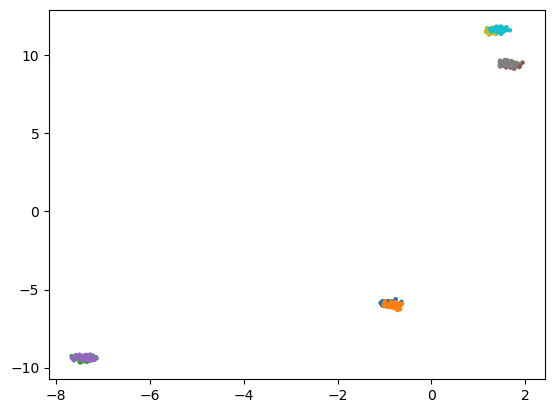

In [178]:
import matplotlib.pyplot as plt
plt.scatter(pts[:, 0], pts[:, 1], c=labels, cmap='tab10', s=5)

In [133]:
W = gl.weightmatrix.knn(pts, k=20, kernel="gaussian")

In [134]:
def plot_graph(X, edge_index, ax, labels=None):
    for i, j in zip(edge_index[0], edge_index[1]):
        ax.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], color='0.8', alpha=0.8, zorder=1) 
    if labels:
        ax.scatter(X[:, 0], X[:, 1], edgecolors='none',  c=labels, cmap='tab10', zorder=2, s=10)
    else:
        ax.scatter(X[:, 0], X[:, 1], edgecolors='none', color='red', zorder=2, s=10)

In [135]:
import datasets.dataset_utils as utils
data = utils.graphlearning_to_pyg(pts, W)

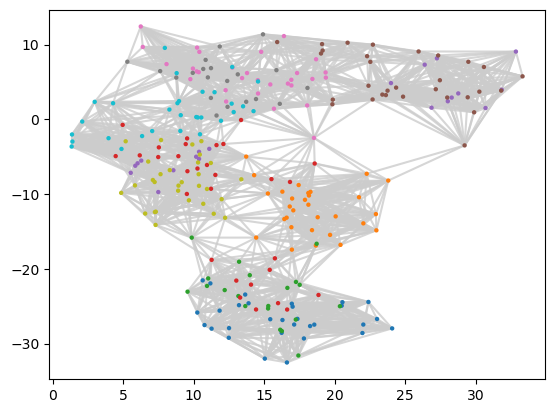

In [136]:
fig, ax = plt.subplots()
plot_graph(pts, data.edge_index, ax, labels=labels)

In [116]:
len(pts)

540